<div style="background:linear-gradient(135deg,#42275a 0%,#734b6d 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🔎&nbsp; Inverse Problems: Learning a Hidden Parameter</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">PINNs shine at <i>inverse</i> problems — recovering unknown physics from sparse, noisy measurements. Here we hide the thermal diffusivity α of the heat equation and let the network discover it from data, jointly with the solution.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">advanced</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">parameter estimation</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">trick</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">α as a learnable tensor</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#603813;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

In a **forward** problem we know the equation and solve for the field. In an **inverse** problem we
have *measurements* of the field and want to recover an unknown coefficient. The PINN trick is
beautiful in its simplicity: just make the unknown a **trainable parameter** and add it to the
optimiser.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#idea" style="color:#1a73e8;text-decoration:none;">1 · The Idea</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">2 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#data" style="color:#1a73e8;text-decoration:none;">3 · Synthetic Measurements</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">4 · Joint Training: Field + Parameter</a></li>
  <li style="margin:3px 0;"><a href="#result" style="color:#1a73e8;text-decoration:none;">5 · Did We Recover α?</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">6 · Takeaways</a></li>
  </ol>
</div>

<a id="idea"></a>

## 1 · The Idea

We observe noisy samples of the temperature $u(t,x)$ governed by the heat equation
$u_t = \alpha\,u_{xx}$, but we **don't know** the diffusivity $\alpha$. We train the network to
(a) match the measurements and (b) satisfy the PDE, where $\alpha$ is *itself* optimised:

$$\mathcal{L}=\underbrace{\frac{1}{N_d}\sum (u_\theta - u_{\text{meas}})^2}_{\text{data}}
+\underbrace{\frac{1}{N_f}\sum\big(u_t-\alpha\,u_{xx}\big)^2}_{\text{physics}},
\qquad \theta,\ \alpha \ \text{both trainable}.$$

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> The physics term is what makes α identifiable: for the measured field, the residual \(u_t-\alpha u_{xx}\) vanishes only at the true diffusivity.
</div>

<a id="setup"></a>

## 2 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="data"></a>

## 3 · Synthetic Measurements

The heat equation has the exact solution $u(t,x)=\sin(\pi x)\,e^{-\alpha\pi^2 t}$. We sample it with the *true* α and add noise to mimic a real experiment.

True (hidden) diffusivity: α = 0.1
800 noisy measurements collected.


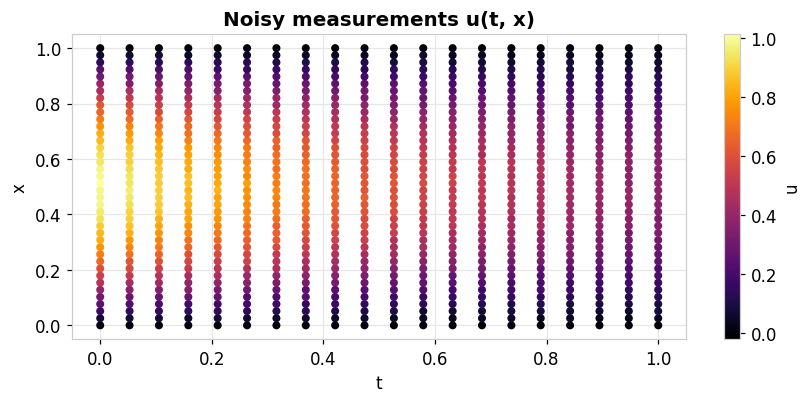

In [2]:
from pinnlab.models import MLP

TRUE_ALPHA = 0.10              # the value we will pretend not to know

def exact(t, x, a):            # exact heat-equation solution
    return np.sin(np.pi * x) * np.exp(-a * np.pi**2 * t)

tm = np.linspace(0, 1, 20, dtype=np.float32)
xm = np.linspace(0, 1, 40, dtype=np.float32)
TM, XM = np.meshgrid(tm, xm, indexing="ij")
U_meas = exact(TM, XM, TRUE_ALPHA) + 0.01 * np.random.randn(*TM.shape)   # noisy

meas_t = torch.tensor(TM.reshape(-1, 1), device=DEVICE)
meas_x = torch.tensor(XM.reshape(-1, 1), device=DEVICE)
meas_u = torch.tensor(U_meas.reshape(-1, 1), device=DEVICE)
print(f"True (hidden) diffusivity: α = {TRUE_ALPHA}")
print(f"{meas_u.numel()} noisy measurements collected.")

fig, ax = plt.subplots(figsize=(9, 3.6))
sc = ax.scatter(TM.ravel(), XM.ravel(), c=U_meas.ravel(), cmap="inferno", s=18)
ax.set(title="Noisy measurements u(t, x)", xlabel="t", ylabel="x")
fig.colorbar(sc, ax=ax, label="u"); plt.show()

<a id="train"></a>

## 4 · Joint Training: Field + Parameter

In [3]:
def heat_residual(model, t, x, alpha):
    t = t.clone().requires_grad_(True); x = x.clone().requires_grad_(True)
    u = model(torch.cat([t, x], dim=1))
    g = lambda y, v: torch.autograd.grad(y, v, torch.ones_like(y),
                                         retain_graph=True, create_graph=True)[0]
    return g(u, t) - alpha * g(g(u, x), x)

torch.manual_seed(SEED)
model = MLP(in_dim=2, hidden_layers=4, width=32, out_dim=1).to(DEVICE)
alpha = torch.nn.Parameter(torch.tensor(0.5, device=DEVICE))     # deliberately wrong guess (5×)
opt = torch.optim.Adam(list(model.parameters()) + [alpha], lr=5e-3)

alpha_history, loss_history = [], []
for step in range(1, 4001):
    t = torch.rand(512, 1, device=DEVICE)
    x = torch.rand(512, 1, device=DEVICE)
    loss_pde  = (heat_residual(model, t, x, alpha) ** 2).mean()
    loss_data = ((model(torch.cat([meas_t, meas_x], 1)) - meas_u) ** 2).mean()
    loss = loss_data + 0.1 * loss_pde
    opt.zero_grad(); loss.backward(); opt.step()
    alpha_history.append(alpha.item()); loss_history.append(loss.item())
    if step % 1000 == 0:
        print(f"step {step:5d} | loss {loss.item():.3e} | α = {alpha.item():.5f}")
print(f"\nRecovered α = {alpha.item():.5f}   (true {TRUE_ALPHA})")

step  1000 | loss 2.389e-04 | α = 0.09804


step  2000 | loss 1.761e-04 | α = 0.10001


step  3000 | loss 1.056e-04 | α = 0.09985


step  4000 | loss 9.983e-05 | α = 0.09984

Recovered α = 0.09984   (true 0.1)


<a id="result"></a>

## 5 · Did We Recover α?

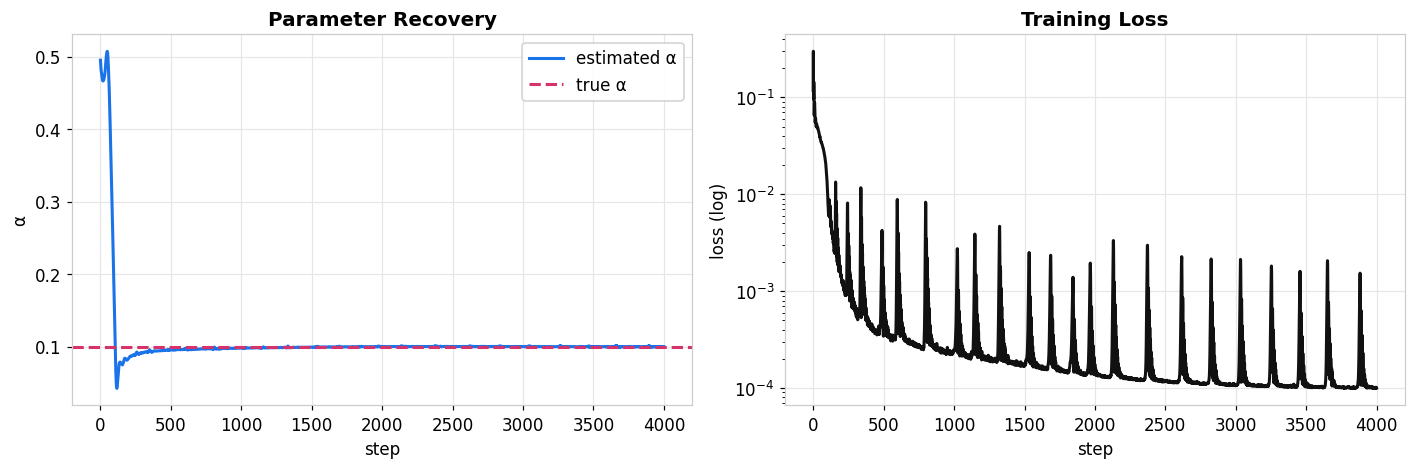

Relative error in recovered α: 0.16%


In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
a1.plot(alpha_history, color=ACCENT, lw=2, label="estimated α")
a1.axhline(TRUE_ALPHA, color=ACCENT2, ls="--", lw=2, label="true α")
a1.set(title="Parameter Recovery", xlabel="step", ylabel="α"); a1.legend()

a2.plot(loss_history, color="#111", lw=2); a2.set_yscale("log")
a2.set(title="Training Loss", xlabel="step", ylabel="loss (log)")
plt.tight_layout(); plt.show()

err = abs(alpha.item() - TRUE_ALPHA) / TRUE_ALPHA * 100
print(f"Relative error in recovered α: {err:.2f}%")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> Starting from a guess 5× too large, the optimiser homes in on the true diffusivity — recovered from a few hundred noisy points. That is the power of embedding physics in the loss.
</div>

<a id="takeaways"></a>

## 6 · Takeaways

- Inverse problems need **one extra line**: wrap the unknown in `torch.nn.Parameter` and add it to
  the optimiser.
- The **PDE residual regularises** the estimate — it constrains the field to be physically
  consistent, making the hidden parameter identifiable even from noisy data.
- The same recipe extends to spatially-varying coefficients, source terms, and boundary fluxes.

**Next:** [`05_uncertainty_quantification`](05_uncertainty_quantification.ipynb) puts error bars on
predictions like these.

### 📚 References

1. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks … inverse problems*. J. Comput. Phys., 378, 686–707.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>